# 문항 1 : 금융위 주식시세정보 API 호출과 오류 처리

공공데이터포털에서 발급받은 서비스키로 금융위원회 주식시세정보 API를 호출하시오.

대상: https://www.data.go.kr/data/15094808/openapi.do

서비스키는 .env로 분리하고, .gitignore에 .env를 추가할 것

코드에 키를 하드코딩하지 않고 불러와 사용할 것

삼성전자(005930) 최근 5영업일 시세를 조회해 JSON을 dict로 파싱할 것

다음 세 가지 오류 상황을 각각 구분해 처리할 것

인증키 오류 (SERVICE_KEY_IS_NOT_REGISTERED_ERROR)

일일 쿼터 초과 (LIMITED_NUMBER_OF_SERVICE_REQUESTS_EXCEEDS_ERROR)

필수 파라미터 누락 (INVALID_REQUEST_PARAMETER_ERROR)

.env.example 파일을 함께 제출할 것 (키 값은 비울 것)

In [3]:
import os
from dotenv import load_dotenv

# 1. .env 파일의 환경변수를 시스템에 로드
load_dotenv()

# 2. os.getenv()를 통해 안전하게 값을 가져와 변수에 할당
API_KEY = os.getenv("DATA_GO_KR_KEY")
DB_PASSWORD = os.getenv("DB_PW")

In [ ]:
import datetime as dt
import requests

In [36]:
# 1. 환경변수 로드 (.env 필수 설정)
load_dotenv()
OPEN_API_KEY = os.getenv("DATA_GO_KR_KEY", "NO_KEY")

# 문서 4페이지의 공식 주식시세 Call Back URL
BASE_URL = "https://apis.data.go.kr/1160100/service/GetStockSecuritiesInfoService/getStockPriceInfo"

# 2. 요청 파라미터 설정
params = {
    "serviceKey": OPEN_API_KEY,
    "resultType": "json",        
    "likeItmsNm": "삼성전자",
    "likeSrtnCd" : "005930",     
    "beginBasDt": "20260820",    
    "endBasDt": "20260827",      
    "numOfRows": 50,   
    "pageNo": 1, 
}

# 3. API 호출 및 HTTP 상태 체크
res = requests.get(BASE_URL, params=params)
res.raise_for_status()

# 4. JSON 문자열을 파이썬 dict 객체로 파싱
data = res.json()

# 파싱된 결과 확인 출력
print("=== 파싱된 JSON dict 데이터 ===")
data

=== 파싱된 JSON dict 데이터 ===


{'response': {'header': {'resultCode': '00', 'resultMsg': 'NORMAL SERVICE.'},
  'body': {'numOfRows': 50,
   'pageNo': 1,
   'totalCount': 5,
   'items': {'item': [{'basDt': '20260826',
      'srtnCd': '005930',
      'isinCd': 'KR7005930003',
      'itmsNm': '삼성전자',
      'mrktCtg': 'KOSPI',
      'clpr': '261500',
      'vs': '4500',
      'fltRt': '1.75',
      'mkp': '256500',
      'hipr': '266500',
      'lopr': '255500',
      'trqu': '19532523',
      'trPrc': '5109878328250',
      'lstgStCnt': '5846278608',
      'mrktTotAmt': '1528801855992000'},
     {'basDt': '20260825',
      'srtnCd': '005930',
      'isinCd': 'KR7005930003',
      'itmsNm': '삼성전자',
      'mrktCtg': 'KOSPI',
      'clpr': '257000',
      'vs': '0',
      'fltRt': '0',
      'mkp': '249000',
      'hipr': '258000',
      'lopr': '245000',
      'trqu': '21617407',
      'trPrc': '5445381811750',
      'lstgStCnt': '5846278608',
      'mrktTotAmt': '1502493602256000'},
     {'basDt': '20260824',
      'srt

In [44]:
# ---------------------------------------------------------------------
#   오류 상황  3가지 구분해 처리
# ---------------------------------------------------------------------

class OpenAPIKeyError(Exception):
    pass

class OpenAPIError(Exception):
    pass

# 환경변수 및 URL
OPEN_API_KEY = os.getenv("DATA_GO_KR_KEY", "")
BASE_URL = "https://apis.data.go.kr/1160100/service/GetStockSecuritiesInfoService/getStockPriceInfo"

def fetch(start_dt, end_dt, item_name, item_code, page=1, size=100) -> dict:
    res = requests.get(BASE_URL, params={
        'serviceKey': OPEN_API_KEY,
        'resultType': 'json',  
        "likeItmsNm": item_name,
        'likeSrtnCd': item_code,
        'beginBasDt': start_dt,
        'endBasDt': end_dt,
        'numOfRows': size,
        'pageNo': page,
    })

    data = res.json()

    # -----------------------------------------------------------------
    # # 1. 키 에러 처리
    # -----------------------------------------------------------------
    if data.get('OpenAPI_ServiceResponse'):
        msg = data.get('OpenAPI_ServiceResponse')['cmmMsgHeader']['errMsg']
        
        if "SERVICE_KEY_IS_NOT_REGISTERED" in msg or "SERVICE_KEY_IS_NULL" in msg:
            raise OpenAPIKeyError("인증키 오류")
        raise OpenAPIKeyError(msg)

    # -----------------------------------------------------------------
    # # 2. 그 외의 에러 처리(일일쿼터 초과, 필수 파라미터 누락)
    # -----------------------------------------------------------------
    if data['response']['header']['resultCode'] != '00':
        msg = data['response']['header']['resultMsg']
        
        if "LIMITED NUMBER OF SERVICE" in msg:
            raise OpenAPIError("일일 쿼터 초과")
        
        elif "INVALID REQUEST PARAMETER" in msg or "NO MANDATORY" in msg:
            raise OpenAPIError("필수 파라미터 누락")
        else:
            raise OpenAPIError(msg)

    return res.url, data

In [45]:
res.url, data = fetch('20260819', '20260827', '삼성전자', '005930', size=100)

In [46]:
import pandas as pd

# 정상적으로 파싱된 dict 데이터에서 주식 시세 리스트(item) 추출
items = data['response']['body']['items']['item']

# 데이터가 1건일 때 dict로 벗겨지는 함정 방어
if isinstance(items, dict):
    items = [items]

# 중첩 JSON 리스트를 한 줄 표 형태로 평탄화 변환
df = pd.json_normalize(items)

column_mapping = {
    "basDt": "기준일자",
    "srtnCd": "단축코드",
    "isinCd": "ISIN코드",
    "itmsNm": "종목명",
    "mrktCtg": "시장구분",
    "clpr": "종가",
    "vs": "대비",
    "fltRt": "등락률",
    "mkp": "시가",
    "hipr": "고가",
    "lopr": "저가",
    "trqu": "거래량",
    "trPrc": "거래대금",
    "lstgStCnt": "상장주식수",
    "mrktTotAmt": "시가총액"
}

df = df.rename(columns=column_mapping)

# === 표 형식 출력 ===
df

,기준일자,단축코드,ISIN코드,종목명,시장구분,종가,대비,등락률,시가,고가,저가,거래량,거래대금,상장주식수,시가총액
0,20260826,005930,KR7005930003,삼성전자,KOSPI,261500,4500,1.75,256500,266500,255500,19532523,5109878328250,5846278608,1528801855992000
1,20260825,005930,KR7005930003,삼성전자,KOSPI,257000,0,0,249000,258000,245000,21617407,5445381811750,5846278608,1502493602256000
2,20260824,005930,KR7005930003,삼성전자,KOSPI,257000,-24500,-8.7,271500,272000,255000,32451940,8456072427750,5846278608,1502493602256000
3,20260821,005930,KR7005930003,삼성전자,KOSPI,281500,10500,3.87,267000,285000,266000,27746471,7703213942500,5846278608,1645727428152000
4,20260820,005930,KR7005930003,삼성전자,KOSPI,271000,23500,9.49,257000,273000,252500,26095919,6961393123500,5846278608,1584341502768000
5,20260819,005930,KR7005930003,삼성전자,KOSPI,247500,-21000,-7.82,251500,254500,246500,22788552,5682871706750,5846278608,1446953955480000


# 문항 2 : DB 스키마 설계와 적재 검증

- 수집한 원본을 보관할 테이블을 만들고, 가공 없이 적재하시오. (과제1의 코드를 활용하여 진행)

1. MariaDB에 fsc_db 데이터베이스를 만들고 전용 계정으로 접속할 것

2. 테이블 raw_item을 다음 컬럼으로 생성할 것 raw_id / source / url / collected_at / payload / content_hash

3. content_hash에 UNIQUE 제약

4. (source, collected_at) 복합 인덱스 설정

5. 다음 10개 종목의 최근 2025년 주식 시세를 수집하여 source='fsc_api' 로, 원문 JSON 그대로 payload에 적재할 것

    CODES = ["005930", "000660", "035420", "051910", "005380",
             "006400", "035720", "068270", "105560", "055550"]
    executemany 배치 삽입 + ON DUPLICATE KEY UPDATE 를 쓸 것

6. 같은 스크립트를 두 번 실행하고, 행 수가 변하지 않음을 SQL로 확인할 것

7. DB 비밀번호도 .env로 관리할 것

8. 참고용 해싱 코드

import hashlib

key_src = '해싱하여 중복되는 값이 들어올 경우 UNIQUE 제약조건을 발생시킬 문자열'
** (예시) fsc_api|20250101|005930
** 수집소스|날짜|주식코드를 해싱하여 같은 값이 또 들어올 경우 Duplicate 처리
hashlib.sha256(key_src.encode()).hexdigest()

In [49]:
import os
import json
import hashlib
import time
from datetime import datetime
import requests
import pymysql
from dotenv import load_dotenv

In [ ]:
# 환경변수 로드
load_dotenv()
OPEN_API_KEY = os.getenv("DATA_GO_KR_KEY", "")

# 데이터베이스 접속 정보 설정
DB_CONFIG = {
    'host': os.getenv('DB_HOST', 'localhost'),
    'port': int(os.getenv('DB_PORT', '3306')),
    'user': os.getenv('DB_USER', 'analysts'),       
    'password': os.getenv('DB_PW', ''),      
    'database': os.getenv('DB_NAME', 'fsc_db'),     
    'charset': 'utf8mb4'
}

BASE_URL = "https://apis.data.go.kr/1160100/service/GetStockSecuritiesInfoService/getStockPriceInfo"


CODES = ["005930", "000660", "035420", "051910", "005380",
         "006400", "035720", "068270", "105560", "055550"]

SOURCE = 'fsc_api'

def fetch_and_insert_all():
    now = datetime.now()
    rows = []
    
    PAGE_SIZE = 200 
    
    print("10개 종목 2025년 시세 데이터 수집 시작")
    
    for code in CODES:
        page = 1
        while True:
            params = {
                "serviceKey": OPEN_API_KEY,
                "resultType": "json",
                "likeSrtnCd": code,
                "beginBasDt": "20250101",  # 2025년 시세 타겟 [조건 5]
                "endBasDt": "20251231",
                "numOfRows": PAGE_SIZE,
                "pageNo": page,
            }
            
            res = requests.get(BASE_URL, params=params)
            res.raise_for_status()
            
            safe_url = res.url.split('serviceKey=')[0] + 'serviceKey=MASKED&' + res.url.split('&', 1)[1] if 'serviceKey=' in res.url else res.url
            
            data = res.json()
            
            body_data = data.get('response', {}).get('body', {})
            items_list = body_data.get('items', {}).get('item', [])
            
            if not items_list:
                break
                
            if isinstance(items_list, dict):
                items_list = [items_list]
                
            
            for item in items_list:
                payload = json.dumps(item, ensure_ascii=False)
                key_src = f"{SOURCE}|{item['basDt']}|{item['srtnCd']}"        # 고유ID 생성
                content_hash = hashlib.sha256(key_src.encode()).hexdigest()   # 해시값으로 변환
                
                rows.append((SOURCE, safe_url, now, payload, content_hash))

                
            total_count = int(body_data.get("totalCount", 0))

            if page * PAGE_SIZE >= total_count:
                break
            page += 1

            time.sleep(5) 
            
        print(f"종목코드 {code} 2025년 수집 완료 (누적 적재대기 데이터: {len(rows)}건)")

    # =========================================================================
    # executemany 배치 삽입 + ON DUPLICATE KEY UPDATE 통합 구현 영역
    # =========================================================================
    if not rows:
        print("적재할 데이터가 존재하지 않습니다.")
        return

    conn = pymysql.connect(**DB_CONFIG)   # SQl연결
    try:
        cur = conn.cursor()
        
        INSERT_SQL = """
            INSERT INTO raw_item (source, url, collected_at, payload, content_hash)
            VALUES (%s, %s, %s, %s, %s)
            ON DUPLICATE KEY UPDATE
                payload = VALUES(payload),
                collected_at = VALUES(collected_at)
        """
        
        cur.executemany(INSERT_SQL, rows)
        conn.commit()
        cur.close()
        print(f"\n[성공] 총 {len(rows)}건의 2025년 시세 데이터 원문 배치 적재 완료!")
        
    except Exception as e:
        print("\nDB 적재 프로세스 중 알 수 없는 에러 발생:", e)
        conn.rollback()
    finally:
        conn.close()

if __name__ == "__main__":
    fetch_and_insert_all()


10개 종목 2025년 시세 데이터 수집 시작
종목코드 005930 2025년 수집 완료 (누적 적재대기 데이터: 242건)
종목코드 000660 2025년 수집 완료 (누적 적재대기 데이터: 484건)
종목코드 035420 2025년 수집 완료 (누적 적재대기 데이터: 726건)
종목코드 051910 2025년 수집 완료 (누적 적재대기 데이터: 968건)
종목코드 005380 2025년 수집 완료 (누적 적재대기 데이터: 1210건)
종목코드 006400 2025년 수집 완료 (누적 적재대기 데이터: 1452건)
종목코드 035720 2025년 수집 완료 (누적 적재대기 데이터: 1694건)
종목코드 068270 2025년 수집 완료 (누적 적재대기 데이터: 1936건)
종목코드 105560 2025년 수집 완료 (누적 적재대기 데이터: 2178건)
종목코드 055550 2025년 수집 완료 (누적 적재대기 데이터: 2420건)

[성공] 총 2420건의 2025년 시세 데이터 원문 배치 적재 완료!


In [ ]:
SELECT COUNT(*) AS total_raw_count 
FROM raw_item;

+-----------------+
| total_raw_count |
+-----------------+
|            2420 |
+-----------------+

SELECT 
    JSON_UNQUOTE(JSON_EXTRACT(payload, '$.srtnCd')) AS 종목코드,
    JSON_UNQUOTE(JSON_EXTRACT(payload, '$.itmsNm')) AS 종목명,
    COUNT(*) AS 적재수
FROM raw_item
WHERE source = 'fsc_api'
GROUP BY 종목코드, 종목명
ORDER BY 종목코드 ASC;

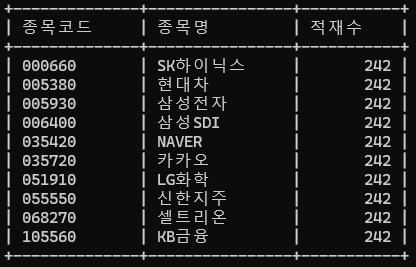